In [1]:
import gymnasium as gym

In [2]:
# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="human")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)
for i in range(1000):
    if i % 100 == 0:
        print(f"Iteration {i}")
    # this is where you would insert your policy
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

env.close()

Iteration 0


Iteration 100


Iteration 200


Iteration 300


Iteration 400


Iteration 500


Iteration 600


Iteration 700


Iteration 800


Iteration 900


In [29]:
from racetrack import RacetrackEnv

env = RacetrackEnv()
observation, info = env.reset(seed=42)
total_reward, done = 0, False
for i in range(1000):
    action = env.action_space.sample()  # replace with a policy
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    done = terminated or truncated
    if done:
        env.reset()

print(env.render())
print("Return:", total_reward, info)

........................F
........................F
........................F
........................F
........................F
........................F
........................F
........................F
........................F
........................F
..........###############
..........###############
..........###############
..........###############
..........###############
..........###############
..........###############
..........###############
..........###############
..........###############
..........###############
..C*......###############
..........###############
..........###############
..........###############
..........###############
..........###############
..........###############
..........###############
SSSSSSSSSS###############
pos=(2, 8) vel=(-2, 1) step=7

None
Return: -16400.0 {'finished': False, 'crashed': False}


### Racetrack position heatmap

Runs many episodes under a random policy and counts how often each `(x, y)` cell is
visited, then plots it with `seaborn.heatmap` (the same plotting call used for
confusion matrices). Off-track cells are masked out so only the track itself is shown.

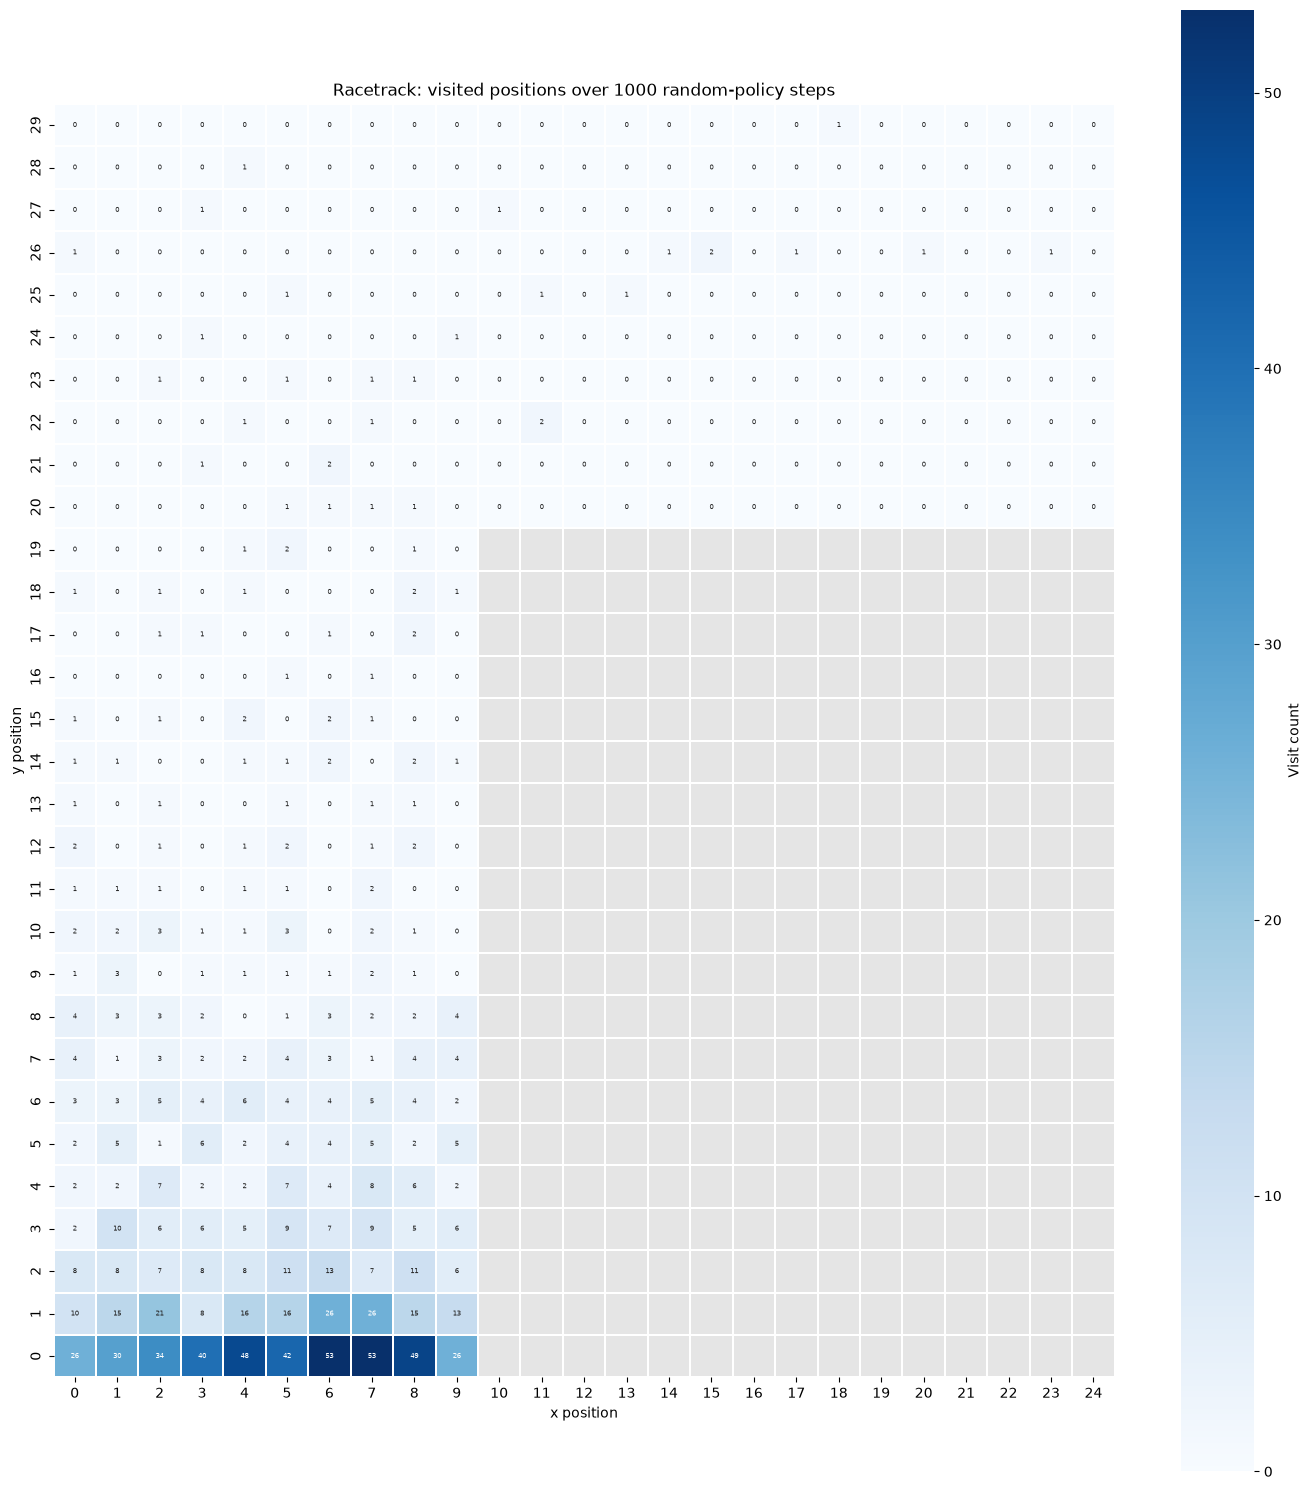

In [34]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from racetrack import RacetrackEnv

track_env = RacetrackEnv()
n_steps = 1000
visits = np.zeros((track_env.height, track_env.width), dtype=int)

track_env.reset(seed=42)
for i in range(n_steps):
    x, y = track_env.pos
    visits[y, x] += 1
    action = track_env.action_space.sample()
    _, _, terminated, truncated, _ = track_env.step(action)
    if terminated or truncated:
        track_env.reset()

mask = ~track_env.track
fig, ax = plt.subplots(figsize=(14, 15))
sns.heatmap(
    visits.astype(float),
    mask=mask,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 5},
    cbar_kws={"label": "Visit count"},
    linewidths=0.1,
    linecolor="white",
    square=True,
    ax=ax,
)
ax.set_facecolor("#e5e5e5")
ax.invert_yaxis()
ax.set_xlabel("x position")
ax.set_ylabel("y position")
ax.set_title(f"Racetrack: visited positions over {n_steps} random-policy steps")
plt.tight_layout()
plt.show()

In [5]:
from chase import ChaseEnv

env = ChaseEnv(size=100)
observation, info = env.reset(seed=42)
total_reward, steps = 0, 0
for i in range(1000):
    action = env.action_space.sample()  # replace with a policy
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1
    done = terminated or truncated
    print(f"Step {steps}: player={info['player_location']}, predator={info['predator_location']}")
    if done:
        env.reset()

print("Return:", total_reward, "Steps:", steps)

Step 1: player=[0.5 0.5], predator=[9.60000387e+01 1.52282302e-02]
Step 2: player=[1.5 1.5], predator=[9.50000515e+01 2.03043069e-02]
Step 3: player=[2.5 2.5], predator=[9.40004107e+01 4.71021857e-02]
Step 4: player=[3. 3.], predator=[90.00251491  0.17683102]
Step 5: player=[3. 2.], predator=[88.00356704  0.24169544]
Step 6: player=[1.5 0. ], predator=[86.00357484  0.23610736]
Step 7: player=[0. 0.], predator=[85.00357861  0.23336205]
Step 8: player=[0. 0.], predator=[82.00358992  0.22512612]
Step 9: player=[0. 0.], predator=[78.00360499  0.21414488]
Step 10: player=[0.5 0. ], predator=[76.00361253  0.20865426]
Step 11: player=[1.5 0. ], predator=[73.00362398  0.20036379]
Step 12: player=[2. 0.], predator=[69.00363991  0.18907631]
Step 13: player=[2. 0.], predator=[66.00365185  0.1806107 ]
Step 14: player=[2.5 0. ], predator=[64.00365982  0.17496696]
Step 15: player=[3.5 0. ], predator=[60.00367654  0.16339965]
Step 16: player=[3. 0.], predator=[59.00368065  0.16053318]
Step 17: player

### Chase position density

`ChaseEnv` positions are continuous, so rather than binning them into grid cells,
this collects the raw `(x, y)` positions visited over many random-policy episodes
and plots a 2D kernel density estimate with `seaborn.kdeplot` for the player and
predator side by side.

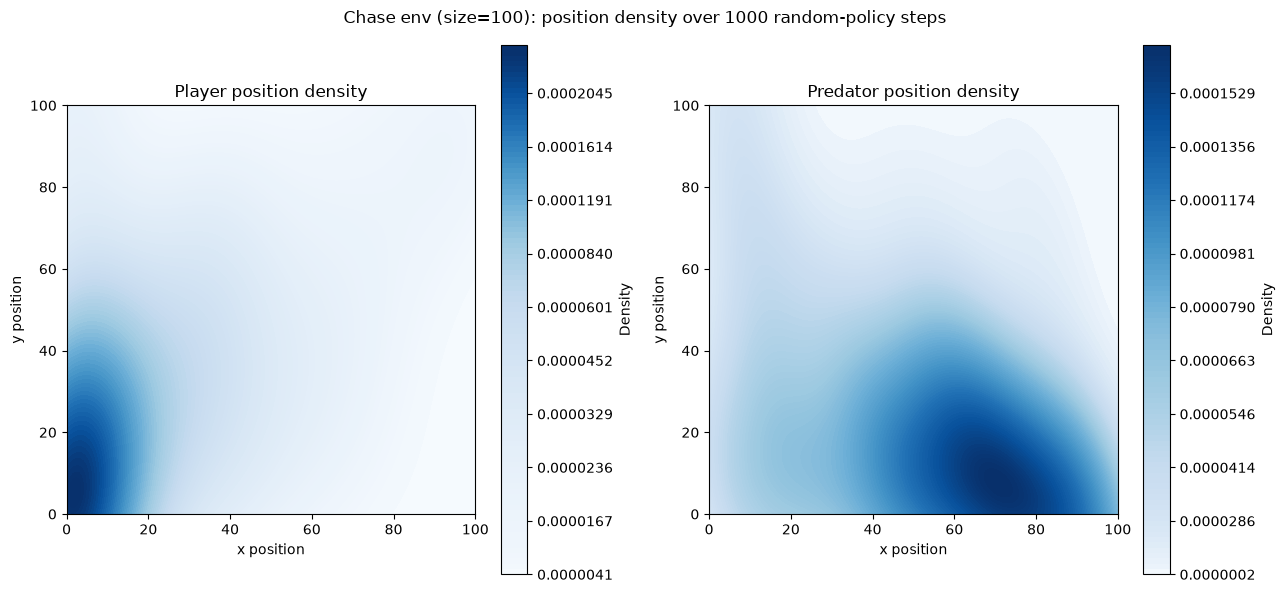

In [32]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from chase import ChaseEnv

chase_size = 100
chase_env = ChaseEnv(size=chase_size)
n_steps = 1000
player_positions = []
predator_positions = []

_, info = chase_env.reset(seed=42)
for i in range(n_steps):
    player_positions.append(info["player_location"].copy())
    predator_positions.append(info["predator_location"].copy())
    action = chase_env.action_space.sample()  # replace with a policy
    _, _, terminated, truncated, info = chase_env.step(action)
    if terminated or truncated:
        _, info = chase_env.reset()

player_positions = np.array(player_positions)
predator_positions = np.array(predator_positions)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, positions, title in zip(
    axes,
    [player_positions, predator_positions],
    ["Player position density", "Predator position density"],
):
    sns.kdeplot(
        x=positions[:, 0],
        y=positions[:, 1],
        fill=True,
        cmap="Blues",
        clip=((0, chase_size), (0, chase_size)),
        thresh=0,
        levels=100,
        cbar=True,
        cbar_kws={"label": "Density"},
        ax=ax,
    )
    ax.set_xlim(0, chase_size)
    ax.set_ylim(0, chase_size)
    ax.set_xlabel("x position")
    ax.set_ylabel("y position")
    ax.set_title(title)
    ax.set_aspect("equal")
fig.suptitle(f"Chase env (size={chase_size}): position density over {n_steps} random-policy steps")
plt.tight_layout()
plt.show()

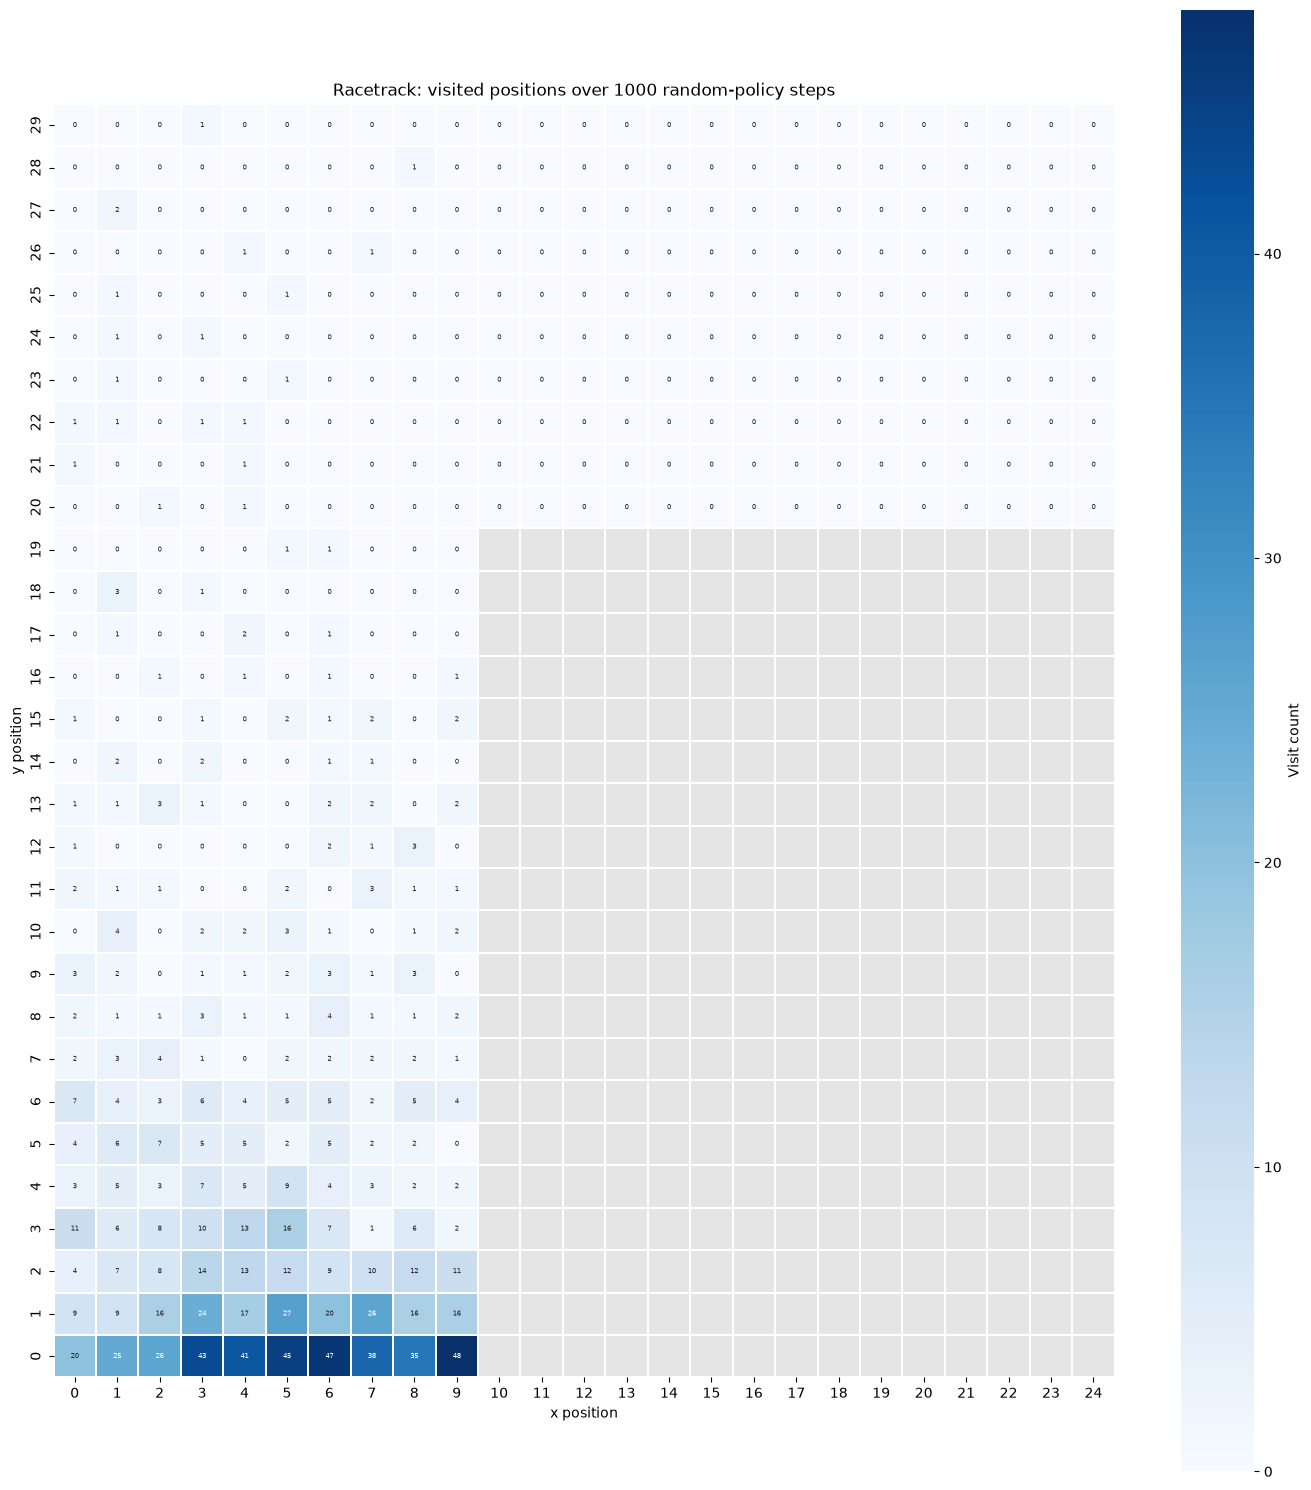

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from racetrack import RacetrackEnv

track_env = RacetrackEnv(wind_speed=2)
n_steps = 1000
visits = np.zeros((track_env.height, track_env.width), dtype=int)

track_env.reset(seed=42)
for i in range(n_steps):
    x, y = track_env.pos
    visits[y, x] += 1
    action = track_env.action_space.sample()
    _, _, terminated, truncated, _ = track_env.step(action)
    if terminated or truncated:
        track_env.reset()

mask = ~track_env.track
fig, ax = plt.subplots(figsize=(14, 15))
sns.heatmap(
    visits.astype(float),
    mask=mask,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 5},
    cbar_kws={"label": "Visit count"},
    linewidths=0.1,
    linecolor="white",
    square=True,
    ax=ax,
)
ax.set_facecolor("#e5e5e5")
ax.invert_yaxis()
ax.set_xlabel("x position")
ax.set_ylabel("y position")
ax.set_title(f"Racetrack: visited positions over {n_steps} random-policy steps")
plt.tight_layout()
plt.show()